In [ ]:
import numpy as np
import pandas as pd

data = pd.read_csv('training_set.csv')
data = data.drop('SampleID', axis=1)

In [77]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = data.drop('label', axis=1)
# Use predicted_labels_from_tsne as the target variable for classification
y_raw = predicted_labels_from_tsne

# Encode the labels to be 0 and 1 for SVM
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

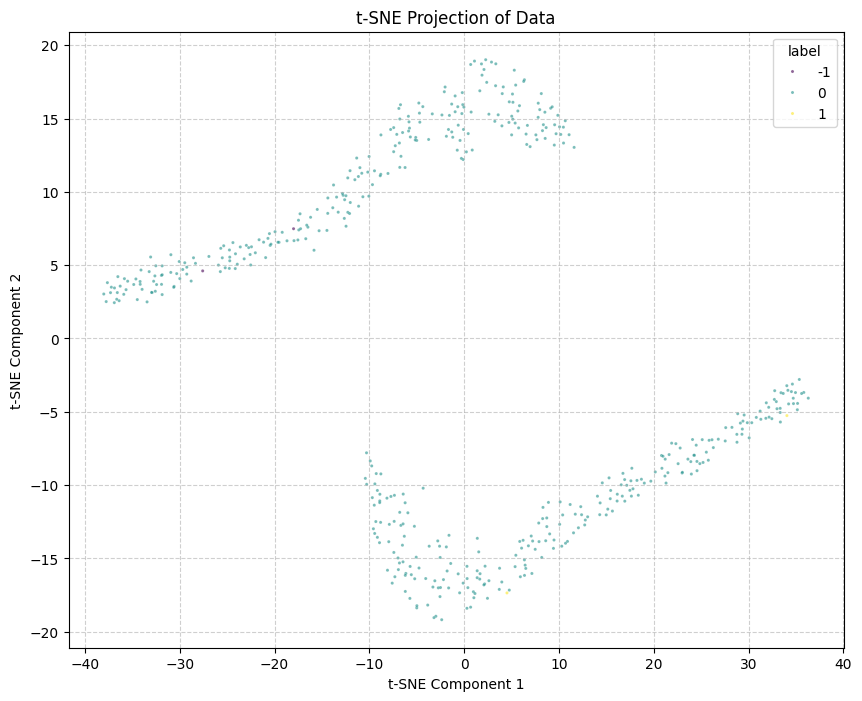

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', legend='full', s=5, alpha=0.6)
plt.title('t-SNE Projection of Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

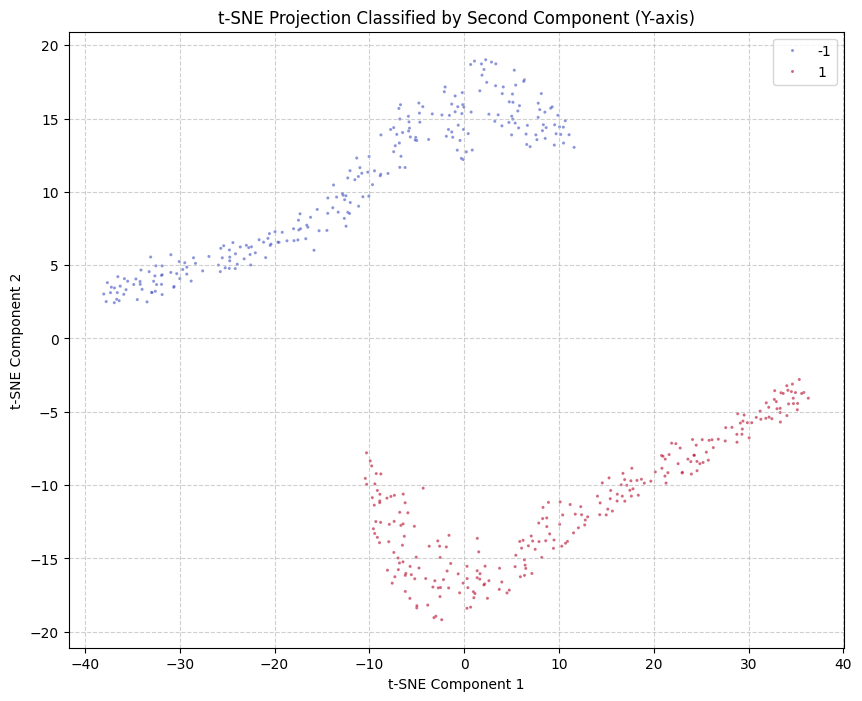

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create new labels based on the second t-SNE component (X_tsne[:, 1]), which corresponds to the y-axis
X_tsne = np.where(X_tsne[:, 1] < 0, 1, -1)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=predicted_labels_from_tsne, palette='coolwarm', legend='full', s=5, alpha=0.6)
plt.title('t-SNE Projection Classified by Second Component (Y-axis)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [81]:
X_tsne

array([[-5.70317554e+00, -1.55451784e+01],
       [-3.48561287e+01,  3.68172240e+00],
       [-2.53668880e+01,  6.32463455e+00],
       [-3.44794006e+01,  2.65341449e+00],
       [ 1.76395264e+01, -1.07503281e+01],
       [ 1.42946272e+01, -1.20139618e+01],
       [-3.32252197e+01,  4.56163979e+00],
       [-3.26248894e+01,  4.26794338e+00],
       [-1.09088257e-01,  1.22033062e+01],
       [-1.64849186e+01,  7.59172344e+00],
       [-5.00469971e+00, -1.83699608e+01],
       [-1.73142967e+01,  8.50311852e+00],
       [-3.77608566e+01,  2.51730657e+00],
       [ 3.27510071e+01, -3.55913997e+00],
       [-3.27599869e+01,  3.90359735e+00],
       [ 6.36191320e+00, -1.61552467e+01],
       [-6.22788715e+00, -1.12031450e+01],
       [-1.43824148e+01,  9.58303833e+00],
       [-5.94071007e+00, -1.18864384e+01],
       [-1.60307634e+00, -1.34223108e+01],
       [-1.13399096e+01,  1.23062487e+01],
       [-7.95733738e+00, -1.38563623e+01],
       [-7.43664789e+00,  1.43812838e+01],
       [ 1.

In [82]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(random_state=42)

model.fit(X_train, y_train)


SVC(random_state=42)

In [87]:
val_data=pd.read_csv('validation_set.csv')
test_data=pd.read_csv('test_set.csv')


val_labels=model.predict(val_data.drop(['SampleID'], axis=1))
#val_labels*=-1
test_labels=model.predict(test_data.drop(['SampleID'], axis=1))
#test_labels*=-1
val_df = pd.DataFrame({
    "SampleID": val_data["SampleID"],
    "ClasamentType": "A",
    "label": val_labels
})

test_df = pd.DataFrame({
    "SampleID": test_data["SampleID"],
    "ClasamentType": "B",
    "label": test_labels
})

submission = pd.concat([val_df, test_df], ignore_index=True)
submission.replace(0, -1, inplace=True)
submission.to_csv("submission.csv", index=False)

submission.head()


,SampleID,ClasamentType,label
0,VALIDATION_001,A,1
1,VALIDATION_002,A,1
2,VALIDATION_003,A,1
3,VALIDATION_004,A,-1
4,VALIDATION_005,A,1
